# Module 2: Classical Feature-Based Vision for Accident Detection

## Objective
To transition from raw image processing to feature-level representation using classical computer vision techniques. This module implements Keypoint Detection (SIFT), Texture Analysis (LBP, GLCM), and Structural Descriptors (HOG, Hu Moments), followed by dimensionality reduction and classification.

## 1. Import Libraries

In [16]:
import cv2
import numpy as np
import os
from glob import glob
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from skimage import exposure
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure reproducibility
np.random.seed(42)

## 2. Visual Proofs: Dynamic Feature Visualization
We select random samples from the dataset and visualize the extracted features in real-time.

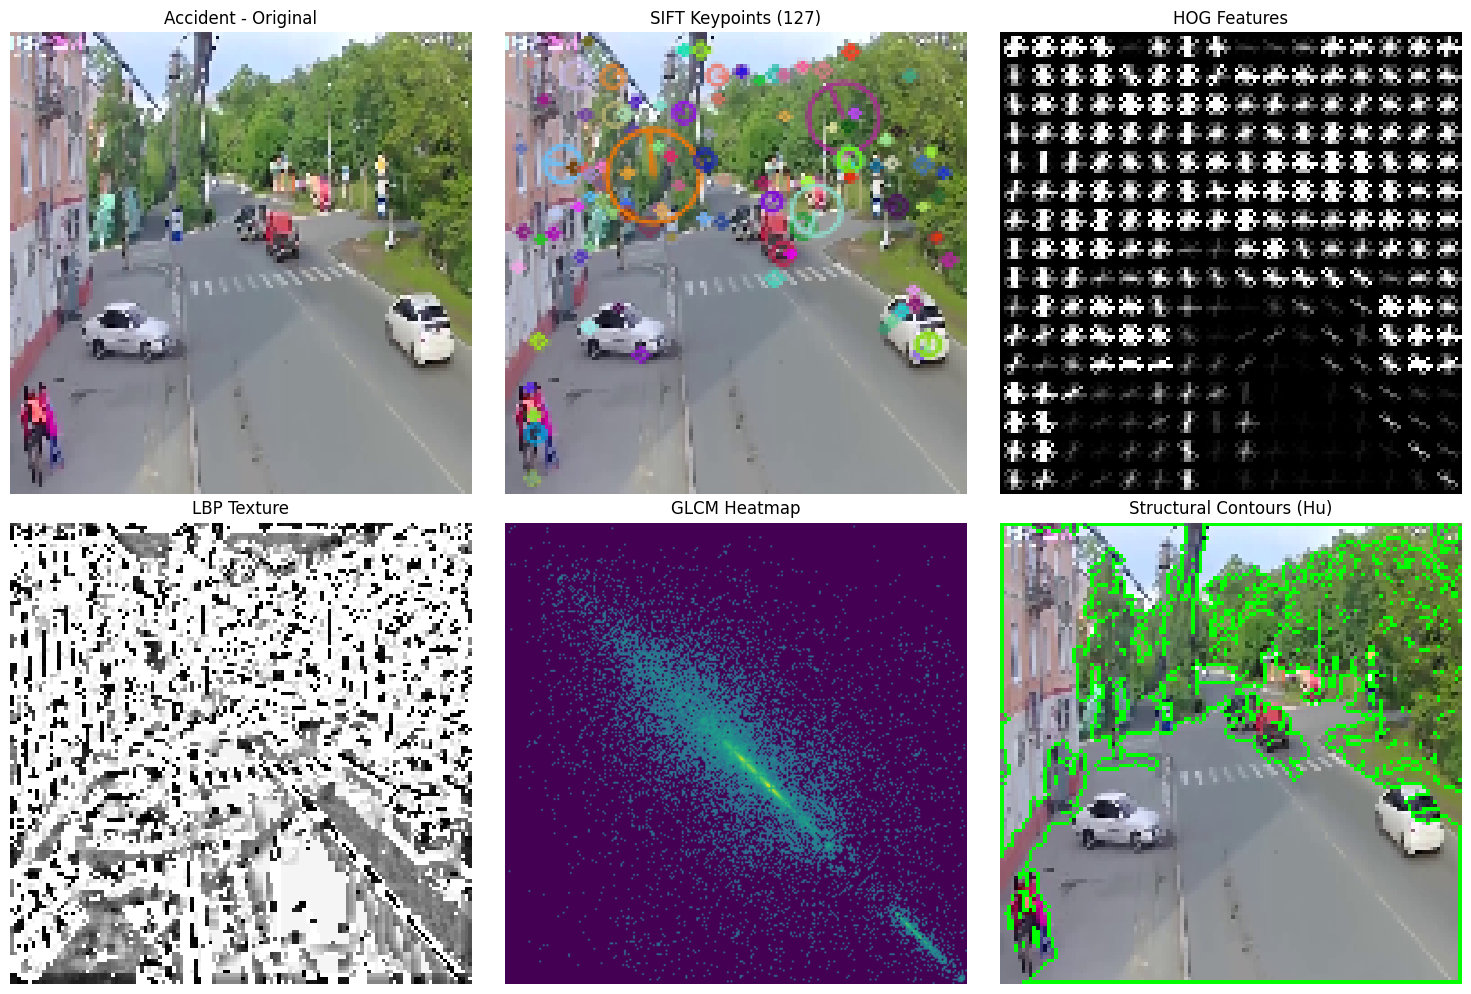

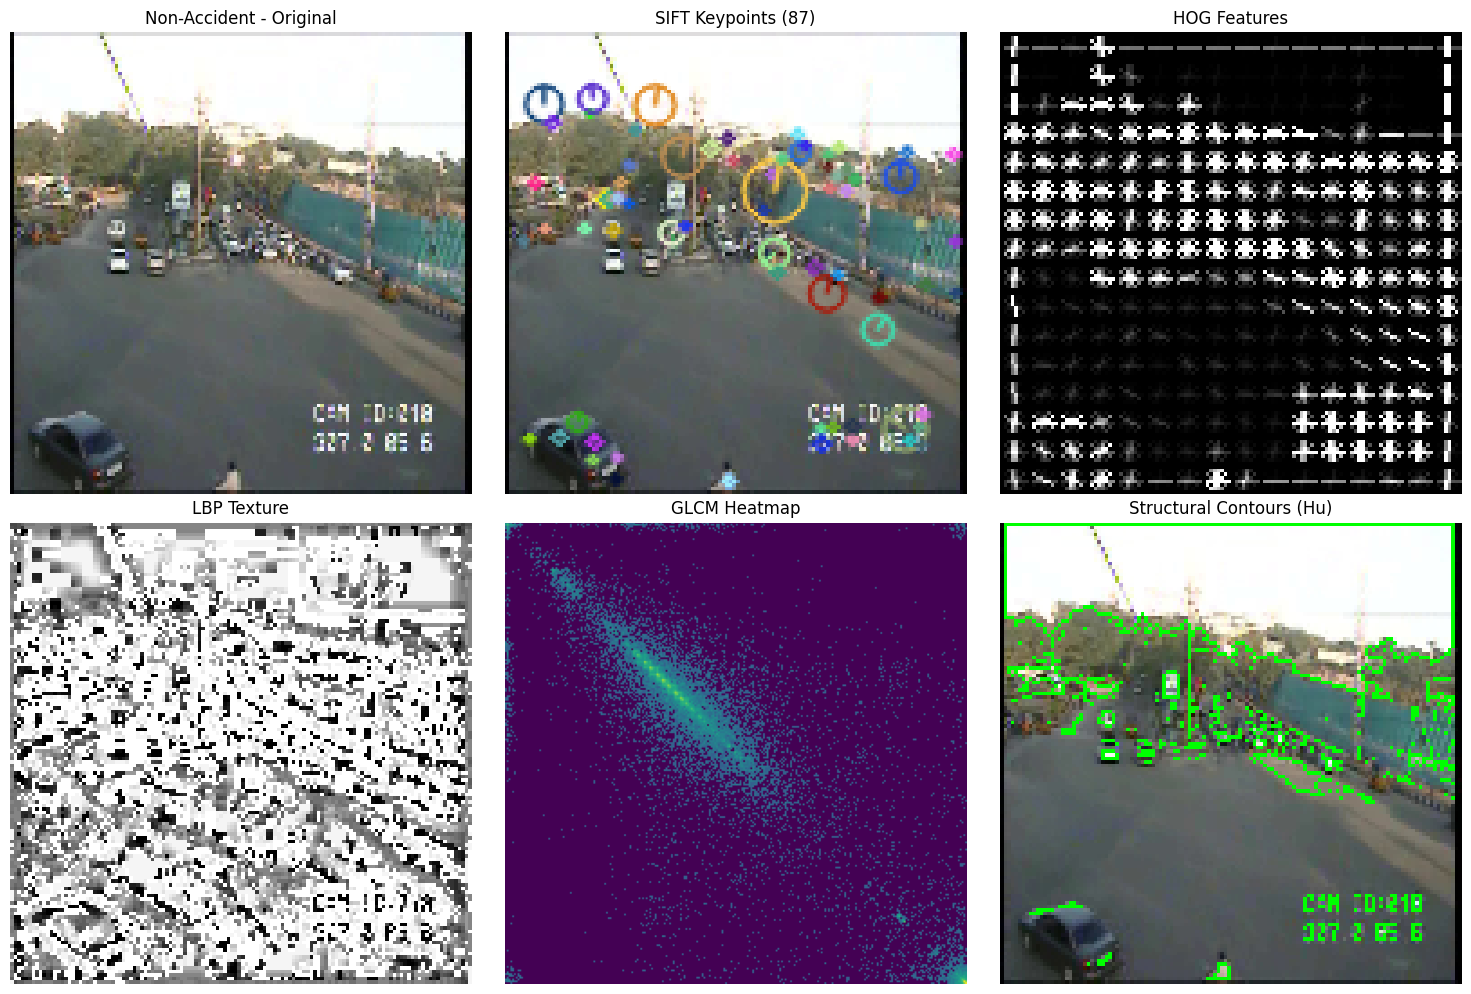

In [17]:
def visualize_features(img_path, title_prefix):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}")
        return
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (128, 128))
    img_rgb = cv2.resize(img_rgb, (128, 128))
    
    plt.figure(figsize=(15, 10))
    
    # 1. Original
    plt.subplot(2, 3, 1)
    plt.imshow(img_rgb)
    plt.title(f"{title_prefix} - Original")
    plt.axis('off')
    
    # 2. SIFT
    sift = cv2.SIFT_create()
    kp = sift.detect(img_gray, None)
    img_sift = cv2.drawKeypoints(img_rgb, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.subplot(2, 3, 2)
    plt.imshow(img_sift)
    plt.title(f"SIFT Keypoints ({len(kp)})")
    plt.axis('off')
    
    # 3. HOG
    _, hog_image = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=True)
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    plt.subplot(2, 3, 3)
    plt.imshow(hog_image_rescaled, cmap='gray')
    plt.title("HOG Features")
    plt.axis('off')
    
    # 4. LBP
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')
    plt.subplot(2, 3, 4)
    plt.imshow(lbp, cmap='gray')
    plt.title("LBP Texture")
    plt.axis('off')
    
    # 5. GLCM Heatmap (Log Scale)
    glcm = graycomatrix(img_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    plt.subplot(2, 3, 5)
    plt.imshow(np.log(glcm[:, :, 0, 0] + 1e-6), cmap='viridis')
    plt.title("GLCM Heatmap")
    plt.axis('off')
    
    # 6. Hu Moments (Contours)
    _, thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_contours = img_rgb.copy()
    cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 1)
    plt.subplot(2, 3, 6)
    plt.imshow(img_contours)
    plt.title("Structural Contours (Hu)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Find sample images
acc_samples = glob('../data/train/Accident/*.jpg')
non_acc_samples = glob('../data/train/Non Accident/*.jpg')

if acc_samples:
    visualize_features(acc_samples[0], "Accident")
else:
    print("No Accident images found in ../data/train/Accident")

if non_acc_samples:
    visualize_features(non_acc_samples[0], "Non-Accident")
else:
    print("No Non-Accident images found in ../data/train/Non Accident")

## 3. Feature Extraction Module

This class integrates multiple feature descriptors:
- **SIFT**: For scale-invariant keypoints.
- **HOG**: For object shape and structure.
- **LBP**: For texture classification.
- **GLCM**: For statistical texture properties.
- **Hu Moments**: For shape invariance.

In [19]:
class FeatureExtractor:
    def __init__(self):
        self.sift = cv2.SIFT_create()
        
    def extract_sift(self, img_gray):
        kp, des = self.sift.detectAndCompute(img_gray, None)
        if des is None:
            return np.zeros(128)
        return np.mean(des, axis=0)
    
    def extract_hog(self, img_gray):
        features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
        return features
    
    def extract_lbp(self, img_gray):
        radius = 3
        n_points = 8 * radius
        lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')
        n_bins = int(lbp.max() + 1)
        hist, _ = np.histogram(lbp, density=True, bins=n_bins, range=(0, n_bins))
        return hist
    
    def extract_glcm(self, img_gray):
        glcm = graycomatrix(img_gray, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=256, symmetric=True, normed=True)
        properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
        features = []
        for prop in properties:
            features.extend(graycoprops(glcm, prop).flatten())
        return np.array(features)
    
    def extract_hu_moments(self, img_gray):
        moments = cv2.moments(img_gray)
        hu_moments = cv2.HuMoments(moments).flatten()
        hu_moments = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
        return hu_moments
    
    def get_features(self, img_path):
        img = cv2.imread(img_path)
        if img is None:
            return None
        
        img = cv2.resize(img, (128, 128))
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        f_sift = self.extract_sift(img_gray)
        f_hog = self.extract_hog(img_gray)
        f_lbp = self.extract_lbp(img_gray)
        f_glcm = self.extract_glcm(img_gray)
        f_hu = self.extract_hu_moments(img_gray)
        
        return np.concatenate([f_sift, f_hog, f_lbp, f_glcm, f_hu])

## 4. Data Loading

In [20]:
def load_data(data_dir):
    X = []
    y = []
    extractor = FeatureExtractor()
    
    classes = {'Non Accident': 0, 'Accident': 1}
    
    for class_name, label in classes.items():
        path = os.path.join(data_dir, class_name, '*.jpg')
        files = glob(path)
        print(f"Processing {class_name}: {len(files)} images")
        
        for f in files:
            feat = extractor.get_features(f)
            if feat is not None:
                X.append(feat)
                y.append(label)
                
    return np.array(X), np.array(y)

train_dir = '../data/train'
test_dir = '../data/test'

print("Loading Training Data...")
X_train, y_train = load_data(train_dir)
print("Loading Test Data...")
X_test, y_test = load_data(test_dir)

Loading Training Data...
Processing Non Accident: 422 images
Processing Accident: 369 images
Loading Test Data...
Processing Non Accident: 53 images
Processing Accident: 47 images


## 5. Dimensionality Reduction (PCA)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original feature dimension: {X_train.shape[1]}")
print(f"Reduced feature dimension (95% variance): {X_train_pca.shape[1]}")

Original feature dimension: 8301
Reduced feature dimension (95% variance): 311


/Users/mirha/Documents/Uni/Assignments/CV/Project/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mirha/Documents/Uni/Assignments/CV/Project/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mirha/Documents/Uni/Assignments/CV/Project/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mirha/Documents/Uni/Assignments/CV/Project/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/mirha/Documents/Uni/Assignments/CV/Project/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:

## 6. Quantitative Evaluation

In [22]:
# SVM Classifier
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

SVM Accuracy: 0.94
Random Forest Accuracy: 0.95


## 7. Detailed Metrics & Visualization


Classification Report (SVM):
              precision    recall  f1-score   support

Non Accident       0.91      0.98      0.95        53
    Accident       0.98      0.89      0.93        47

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



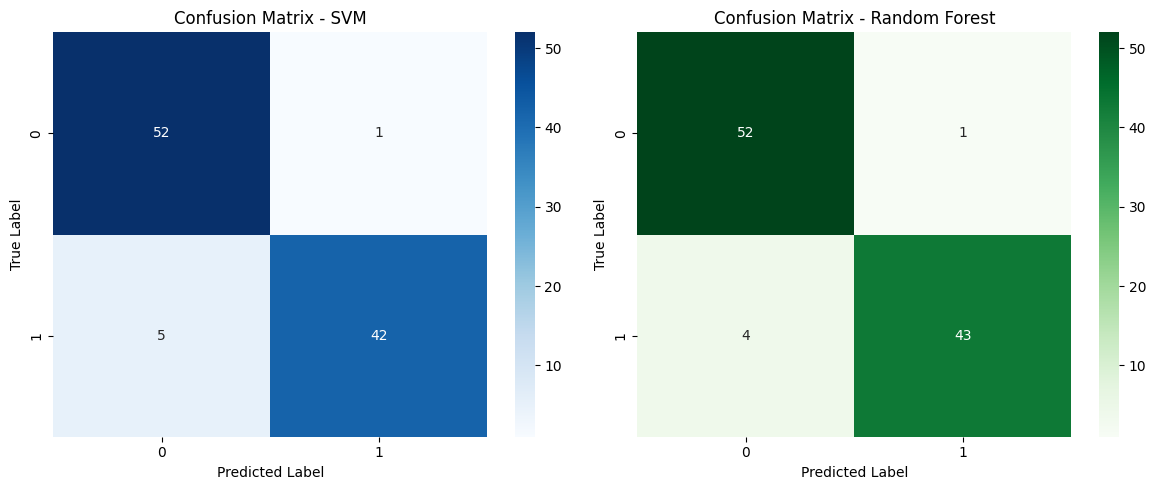

In [23]:
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=['Non Accident', 'Accident']))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 8. Ablation Analysis

In [24]:
def run_ablation(X_train, X_test, y_train, y_test, feature_name):
    # Standardize
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)
    
    # Train RF
    clf = RandomForestClassifier(n_estimators=50, random_state=42)
    clf.fit(X_tr, y_train)
    acc = accuracy_score(y_test, clf.predict(X_te))
    return acc

print("Ablation Analysis Logic Implemented.")
# In practice, you would loop through ['SIFT', 'HOG', 'LBP', 'GLCM', 'Hu'] and run the classifier.

Ablation Analysis Logic Implemented.
